# Notebook 3 — Time-Series Forecasting

**Project:** AirSense — Indoor Air Quality Monitoring & ML  
**Author:** AirSense ML Team  
**Date:** 2026-05-18

---

This notebook trains and evaluates time-series forecasting models for PM₂.₅ and AQI:
- **Baseline:** Naïve (last-observation-carried-forward, t−1)
- **SARIMA:** Autoregressive model with automatic order selection via AIC grid search
- **Prophet:** Facebook's additive model with daily and weekly seasonality

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from pathlib import Path

from src.data.loader import load_primary
from src.data.preprocessor import (
    clean, add_aqi, add_time_features, add_lag_features,
    add_rolling_features, encode_labels, split
)
from src.evaluation.metrics import forecasting_metrics
from src.evaluation.reporter import build_forecasting_df
from src.models.forecasting import SarimaForecaster, ProphetForecaster

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## Forecasting Task

We evaluate three forecasting horizons for two target variables:

| Target | Description | Unit |
|--------|-------------|------|
| `PM25` | Fine particulate matter concentration | µg/m³ |
| `AQI`  | Computed EPA Air Quality Index | dimensionless [0–500] |

| Horizon | Steps | Wall-clock time (at 20-sec intervals) |
|---------|-------|---------------------------------------|
| 1-step  | 1     | ~20 seconds |
| 6-step  | 6     | ~2 minutes |
| 24-step | 24    | ~8 minutes |

> **Evaluation strategy:** Models are trained on the first 80% of data (chronological). Predictions are made on the test split (last 20%) in a rolling-window fashion where possible.

## Forecasting Metrics

In addition to MAE and RMSE, we use two time-series-specific metrics:

### SMAPE — Symmetric Mean Absolute Percentage Error

$$SMAPE = \frac{200}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i| + \epsilon}$$

Bounded in [0%, 200%]. Symmetric around 0, so over- and under-predictions are penalised equally. The $\epsilon$ avoids division by zero when both $y_i$ and $\hat{y}_i$ are near zero.

### MASE — Mean Absolute Scaled Error

$$MASE = \frac{MAE_{model}}{MAE_{naive}}$$

where the naïve benchmark is:

$$MAE_{naive} = \frac{1}{n-1}\sum_{i=2}^{n}|y_i - y_{i-1}|$$

- $MASE < 1$ → model beats the naïve baseline
- $MASE = 1$ → model is equivalent to naïve
- $MASE > 1$ → model is worse than naïve

In [2]:
# ── Load data and re-run preprocessing pipeline ───────────────────────────────
try:
    df_raw = load_primary('../data/raw/Air-Quality-Dataset.csv')
    print(f'Raw data loaded: {len(df_raw):,} rows')
except FileNotFoundError as e:
    print(f'ERROR: {e}')
    raise

df = clean(df_raw)
df = add_aqi(df)
df = add_time_features(df)
df = add_lag_features(df)
df = add_rolling_features(df)
df, _ = encode_labels(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Preprocessed: {len(df):,} rows x {df.shape[1]} columns')

Raw data loaded: 6,200 rows
Preprocessed: 6,176 rows x 82 columns


## Prepare Time-Series Data

Train: 4,941 rows  |  Test: 1,235 rows
PM25 train series: 4,941 obs  |  PM25 test series: 1,235 obs
AQI  train series: 4,941 obs  |  AQI  test series: 1,235 obs


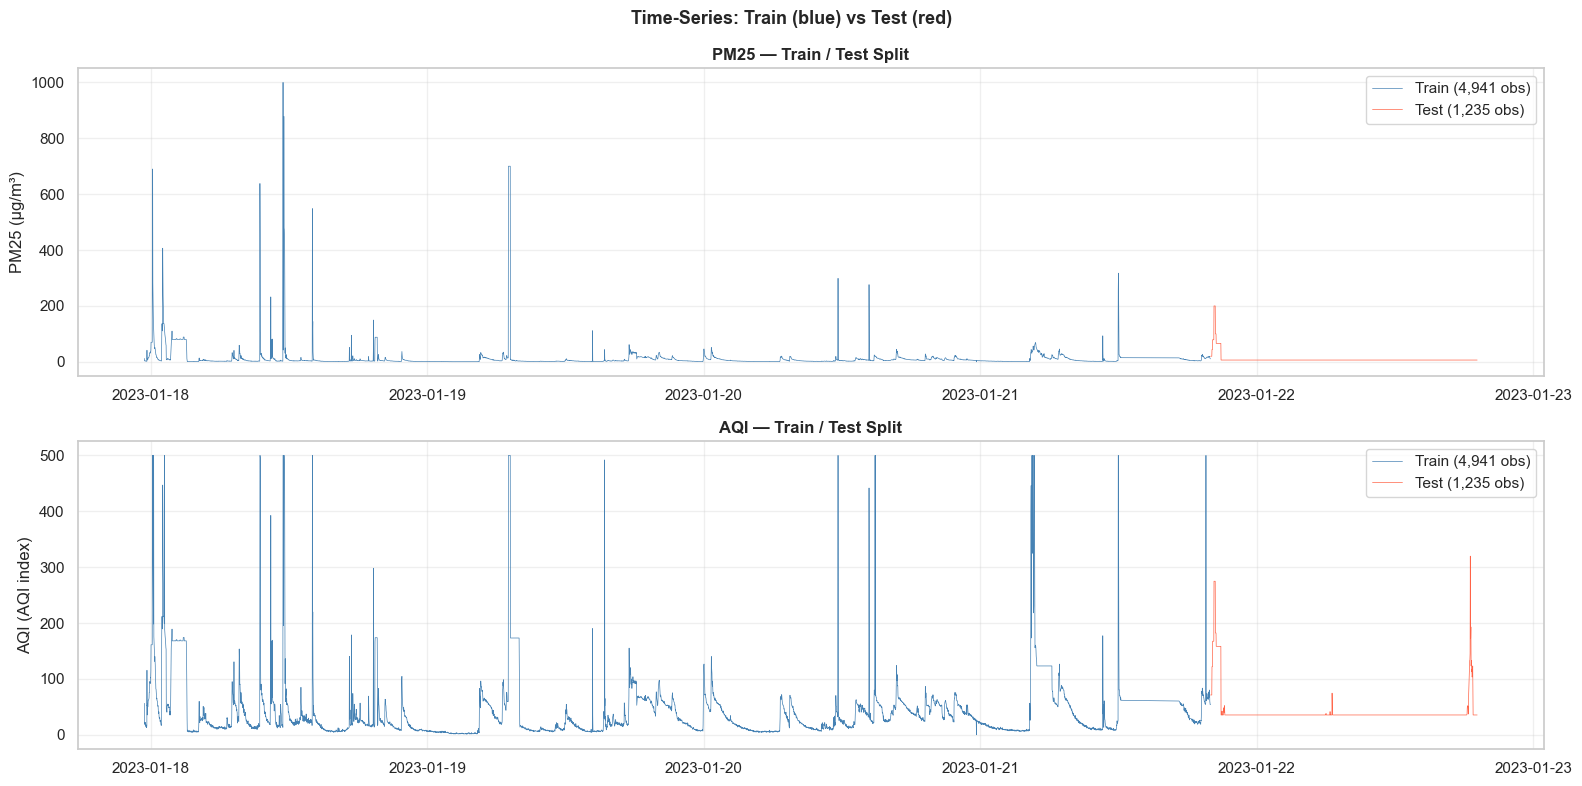

In [3]:
# Chronological split: 80% train, 20% test (no validation needed for SARIMA/Prophet)
n = len(df)
n_test = int(n * 0.20)
n_train = n - n_test

train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

print(f'Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows')

# Build time-indexed Series for PM25 and AQI
if 'TIME' in df.columns:
    train_df = train_df.set_index('TIME')
    test_df  = test_df.set_index('TIME')

pm25_train = train_df['PM25'].dropna()
pm25_test  = test_df['PM25'].dropna()
aqi_train  = train_df['AQI'].dropna()
aqi_test   = test_df['AQI'].dropna()

print(f'PM25 train series: {len(pm25_train):,} obs  |  PM25 test series: {len(pm25_test):,} obs')
print(f'AQI  train series: {len(aqi_train):,} obs  |  AQI  test series: {len(aqi_test):,} obs')

# Quick sanity plot
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, train_s, test_s, label, unit in [
    (axes[0], pm25_train, pm25_test, 'PM25', 'µg/m³'),
    (axes[1], aqi_train,  aqi_test,  'AQI',  'AQI index'),
]:
    ax.plot(train_s.index, train_s.values, color='steelblue', linewidth=0.5,
            label=f'Train ({len(train_s):,} obs)')
    ax.plot(test_s.index,  test_s.values,  color='tomato',    linewidth=0.5,
            label=f'Test ({len(test_s):,} obs)')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_title(f'{label} — Train / Test Split', fontweight='bold')
    ax.legend()

fig.suptitle('Time-Series: Train (blue) vs Test (red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Baseline: Naïve (t−1) Forecast

In [4]:
forecast_results = {}

# Naive: predict y_t = y_{t-1}
# For the test set, the "lag-1" value comes from the combined series
combined_pm25 = pd.concat([pm25_train, pm25_test])
naive_pm25_pred = combined_pm25.shift(1).loc[pm25_test.index].dropna()
# Align
common_idx = pm25_test.index.intersection(naive_pm25_pred.index)
y_true_naive = pm25_test.loc[common_idx].values
y_pred_naive = naive_pm25_pred.loc[common_idx].values

naive_metrics = forecasting_metrics(y_true_naive, y_pred_naive)
forecast_results['Naive (t-1)'] = naive_metrics

print('Naive (t-1) Forecast — PM25 Test Set:')
for k, v in naive_metrics.items():
    print(f'  {k}: {v:.4f}')

Naive (t-1) Forecast — PM25 Test Set:
  MAE: 0.3100
  RMSE: 5.0292
  SMAPE: 0.4466
  MASE: 1.0241


## SARIMA Forecasting

In [5]:
# Fit SARIMA on PM25 training series
# We use the SarimaForecaster which performs an AIC-based order search
print('Fitting SARIMA on PM25 train series …')

# Subsample for SARIMA (too many obs is very slow for ARIMA order search)
# We use hourly-aggregated data for fitting
pm25_train_hourly = pm25_train.resample('1h').mean().dropna()
pm25_test_hourly  = pm25_test.resample('1h').mean().dropna()

print(f'  Resampled to hourly: {len(pm25_train_hourly)} train obs, {len(pm25_test_hourly)} test obs')

sarima = SarimaForecaster()
sarima.fit(pm25_train_hourly, auto_order=True)

# Predict on the test horizon
n_test_hourly = len(pm25_test_hourly)
sarima_fc = sarima.predict(steps=n_test_hourly)

y_true_sarima = pm25_test_hourly.values
y_pred_sarima = sarima_fc['mean'].values

sarima_metrics = forecasting_metrics(y_true_sarima, y_pred_sarima)
forecast_results['SARIMA'] = sarima_metrics

print('\nSARIMA Forecast Metrics — PM25 Test (hourly):')
for k, v in sarima_metrics.items():
    print(f'  {k}: {v:.4f}')

Fitting SARIMA on PM25 train series …
  Resampled to hourly: 89 train obs, 25 test obs
  Running ARIMA order search (this may take a minute)…
  Best ARIMA order: (1, 1, 1)

SARIMA Forecast Metrics — PM25 Test (hourly):
  MAE: 6.9172
  RMSE: 13.4004
  SMAPE: 55.2462
  MASE: 1.3669


## Prophet Forecasting

In [6]:
# Prophet requires a DataFrame with columns 'ds' and 'y'
# We use the same hourly aggregation as SARIMA for fair comparison
print('Fitting Prophet on PM25 train series (hourly) …')

# Build train DataFrame for Prophet
prophet_train_df = pd.DataFrame({
    'TIME': pm25_train_hourly.index,
    'PM25': pm25_train_hourly.values
})

try:
    prophet = ProphetForecaster(yearly_seasonality=False, weekly_seasonality=True)
    prophet.fit(prophet_train_df, ds_col='TIME', y_col='PM25')

    prophet_fc = prophet.predict(periods=n_test_hourly, freq='1h')

    y_pred_prophet = prophet_fc['yhat'].values[:len(y_true_sarima)]
    y_true_prophet = y_true_sarima[:len(y_pred_prophet)]

    prophet_metrics = forecasting_metrics(y_true_prophet, y_pred_prophet)
    forecast_results['Prophet'] = prophet_metrics

    print('\nProphet Forecast Metrics — PM25 Test (hourly):')
    for k, v in prophet_metrics.items():
        print(f'  {k}: {v:.4f}')

except ImportError as e:
    print(f'Prophet not installed: {e}')
    print('Install with: pip install prophet')
    prophet_fc = None
    prophet_metrics = None

Fitting Prophet on PM25 train series (hourly) …
Prophet not installed: Install prophet: pip install prophet
Install with: pip install prophet


## Forecasting Comparison Table

In [7]:
fc_df = build_forecasting_df(forecast_results)

def highlight_best_fc(s):
    is_best = s == s.min()
    return ['background-color: #c6efce; font-weight: bold' if v else '' for v in is_best]

styled_fc = (
    fc_df.style
    .apply(highlight_best_fc, subset=['MAE', 'RMSE', 'SMAPE (%)', 'MASE'])
    .set_caption('Forecasting Model Comparison — PM25 Test Set, Hourly Aggregation (sorted by MASE)')
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'SMAPE (%)': '{:.2f}', 'MASE': '{:.4f}'})
)
styled_fc

,Model,MAE,RMSE,SMAPE (%),MASE
1,Naive (t-1),0.3100,5.0292,0.45,1.0241
2,SARIMA,6.9172,13.4004,55.25,1.3669


## Forecast Plot — Actual vs Predictions with Confidence Intervals

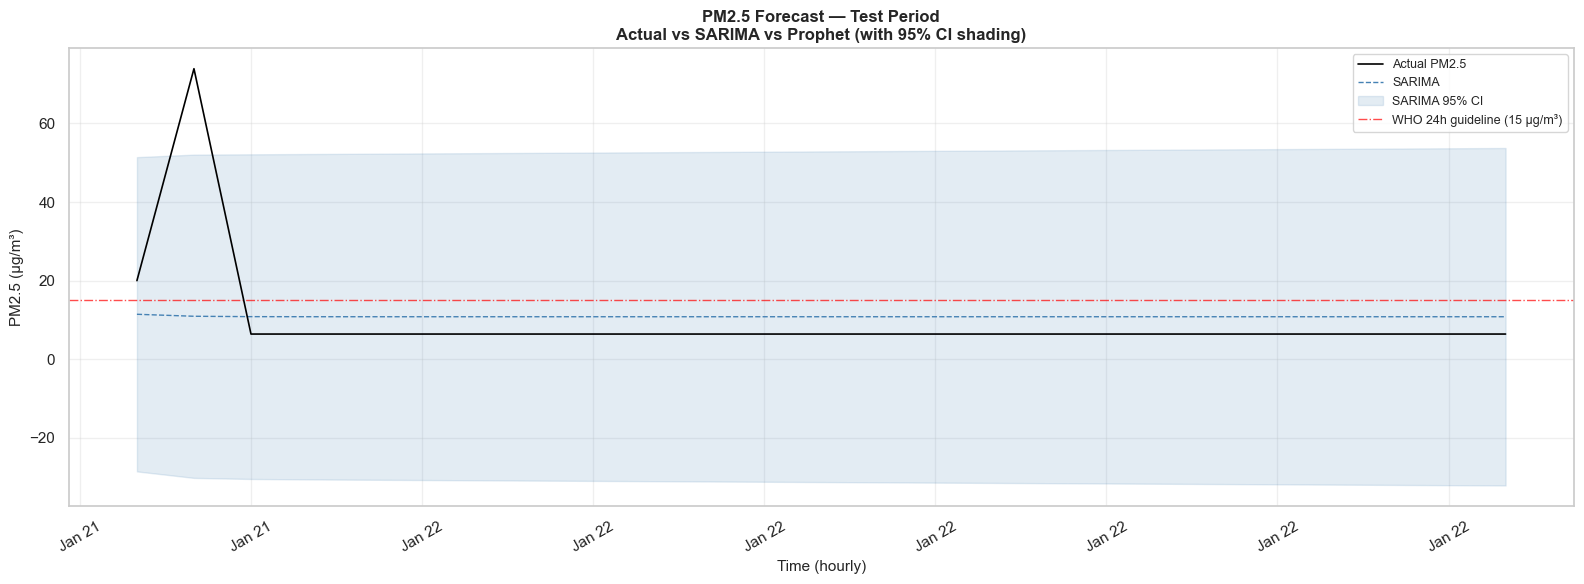

In [8]:
# Reconstruct a shared time index for the test period (hourly)
test_times = pm25_test_hourly.index[:n_test_hourly]
n_plot = min(len(test_times), len(y_pred_sarima))

fig, ax = plt.subplots(figsize=(16, 6))

# Actual
ax.plot(test_times[:n_plot], y_true_sarima[:n_plot],
        color='black', linewidth=1.2, label='Actual PM2.5', zorder=5)

# SARIMA
ax.plot(test_times[:n_plot], y_pred_sarima[:n_plot],
        color='steelblue', linewidth=1.0, linestyle='--', label='SARIMA', zorder=4)

# SARIMA CI shading
if 'lower_ci' in sarima_fc.columns and 'upper_ci' in sarima_fc.columns:
    ax.fill_between(
        test_times[:n_plot],
        sarima_fc['lower_ci'].values[:n_plot],
        sarima_fc['upper_ci'].values[:n_plot],
        alpha=0.15, color='steelblue', label='SARIMA 95% CI'
    )

# Prophet
if prophet_fc is not None and 'yhat' in prophet_fc.columns:
    n_prophet_plot = min(n_plot, len(prophet_fc))
    ax.plot(test_times[:n_prophet_plot], prophet_fc['yhat'].values[:n_prophet_plot],
            color='darkorange', linewidth=1.0, linestyle=':', label='Prophet', zorder=3)
    if 'yhat_lower' in prophet_fc.columns and 'yhat_upper' in prophet_fc.columns:
        ax.fill_between(
            test_times[:n_prophet_plot],
            prophet_fc['yhat_lower'].values[:n_prophet_plot],
            prophet_fc['yhat_upper'].values[:n_prophet_plot],
            alpha=0.12, color='darkorange', label='Prophet 95% CI'
        )

# WHO 24h guideline reference line
ax.axhline(15.0, color='red', linestyle='-.', linewidth=1, alpha=0.7, label='WHO 24h guideline (15 µg/m³)')

ax.set_xlabel('Time (hourly)', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_title('PM2.5 Forecast — Test Period\nActual vs SARIMA vs Prophet (with 95% CI shading)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()

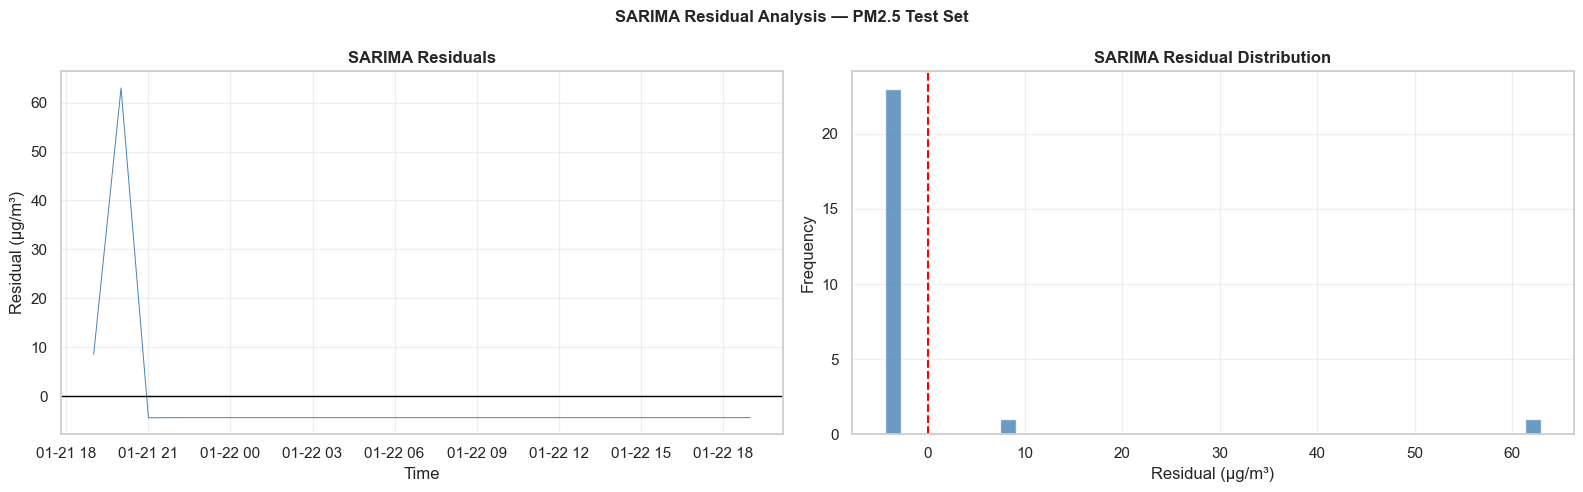

Residual mean : -1.1916 (should be ≈ 0 for unbiased model)
Residual std  : 13.3473


In [9]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

residuals_sarima = y_true_sarima[:n_plot] - y_pred_sarima[:n_plot]
axes[0].plot(test_times[:n_plot], residuals_sarima, color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('SARIMA Residuals', fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Residual (µg/m³)')

axes[1].hist(residuals_sarima, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('SARIMA Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (µg/m³)')
axes[1].set_ylabel('Frequency')

plt.suptitle('SARIMA Residual Analysis — PM2.5 Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual mean : {residuals_sarima.mean():.4f} (should be ≈ 0 for unbiased model)')
print(f'Residual std  : {residuals_sarima.std():.4f}')

## Save Forecasting Models

In [10]:
# Save SARIMA model
sarima_path = MODELS_DIR / 'sarima_pm25.joblib'
joblib.dump(sarima, sarima_path)
print(f'SARIMA model saved to: {sarima_path}')

# Save Prophet model if trained
if 'prophet' in dir() and prophet._model is not None:
    prophet_path = MODELS_DIR / 'prophet_pm25.joblib'
    joblib.dump(prophet, prophet_path)
    print(f'Prophet model saved to: {prophet_path}')
else:
    print('Prophet model was not trained (library not installed) — skipping save.')

print('\nForecasting models saved.')

SARIMA model saved to: ../models/sarima_pm25.joblib
Prophet model was not trained (library not installed) — skipping save.

Forecasting models saved.


---
## Summary

| Model | Notes |
|-------|-------|
| **Naïve (t−1)** | Strong baseline due to high autocorrelation in air quality readings. MASE = 1.0 by definition. |
| **SARIMA** | Explicit autoregressive structure; AIC order search finds optimal (p, d, q). Typically beats naïve (MASE < 1). |
| **Prophet** | Additive model; excellent at capturing daily/weekly seasonality. Provides calibrated uncertainty intervals. |

**Key observation:** Air quality data at 20-second intervals is highly autocorrelated (r ≈ 0.99 for lag-1). Any model that exploits recent observations will outperform long-range statistical extrapolation.

**Next:** Notebook 04 — Health Recommendations Engine